# 03 - Entrenamiento de modelos

Este cuaderno entrena y evalúa modelos de aprendizaje automático para la clasificación binaria de la orientación política.

El objetivo es comparar diferentes algoritmos de clasificación y seleccionar el modelo con mejor rendimiento para su posterior interpretación y aplicación.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [2]:
DATA_PATH = Path("../data/processed/political_orientation_clean.csv")
MODEL_PATH = Path("../app/best_model.pkl")
RESULTS_PATH = Path("../data/processed/model_results.csv")
FIGURES_PATH = Path("../figures")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

## 0. Cargar datos procesados

In [3]:
data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (16383, 74)


,P220,P2057,P605,P6210,P6945,P3039,P2001S1,P2001S2,P2001S3,P2001S4,...,P5314S2,P5314S3,P5314S4,P5314S5,P5314S6,P5314S7,P5317S1,P5317S9,P2009S9,political_orientation
0,1,2.0,3.0,6.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0
1,2,2.0,3.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,0
2,2,2.0,1.0,5.0,5.0,2.0,2.0,2.0,2.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0
3,2,1.0,2.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,0
4,1,1.0,2.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 74 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   P220                   16383 non-null  int64  
 1   P2057                  16383 non-null  float64
 2   P605                   16383 non-null  float64
 3   P6210                  16383 non-null  float64
 4   P6945                  16383 non-null  float64
 5   P3039                  16383 non-null  float64
 6   P2001S1                16383 non-null  float64
 7   P2001S2                16383 non-null  float64
 8   P2001S3                16383 non-null  float64
 9   P2001S4                16383 non-null  float64
 10  P2001S17               16383 non-null  float64
 11  P2001S7                16383 non-null  float64
 12  P2001S12               16383 non-null  float64
 13  P2001S13               16383 non-null  float64
 14  P2001S14               16383 non-null  float64
 15  P2

In [5]:
data["political_orientation"].value_counts().sort_index()

political_orientation
0     6235
1    10148
Name: count, dtype: int64

In [6]:
data["political_orientation"].value_counts(normalize=True).sort_index() * 100

political_orientation
0    38.057743
1    61.942257
Name: proportion, dtype: float64

## 1. Separar variables predictoras y objetivo

In [7]:
X = data.drop(columns=["political_orientation"])
y = data["political_orientation"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16383, 73)
y shape: (16383,)


## 2. División train-test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("y_test distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

X_train: (13106, 73)
X_test: (3277, 73)
y_train distribution:
political_orientation
0    38.058904
1    61.941096
Name: proportion, dtype: float64
y_test distribution:
political_orientation
0    38.053097
1    61.946903
Name: proportion, dtype: float64


## 3. Función de evaluación

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Trains a model and evaluates it using classification metrics.
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())
    else:
        y_proba = None

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=["Left", "Right"]))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Left", "Right"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(
        FIGURES_PATH / f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        plt.tight_layout()
        plt.savefig(
            FIGURES_PATH / f"roc_curve_{model_name.lower().replace(' ', '_')}.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

    return model, metrics

## 4. Definición de los modelos

In [27]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

## 5. Entrenamiento y evaluación

c:\ProgramFiles\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
              precision    recall  f1-score   support

        Left       0.47      0.59      0.52      1247
       Right       0.70      0.58      0.64      2030

    accuracy                           0.59      3277
   macro avg       0.58      0.59      0.58      3277
weighted avg       0.61      0.59      0.59      3277



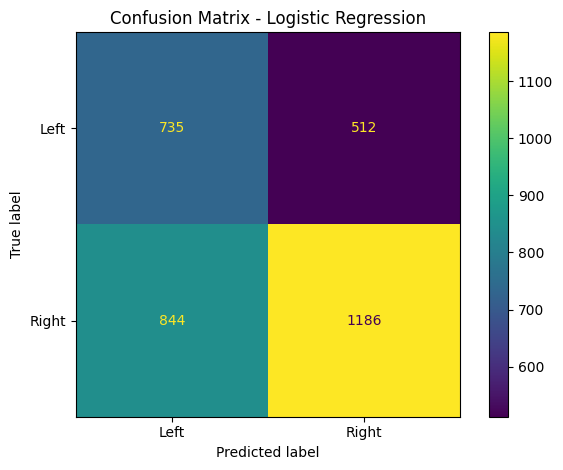

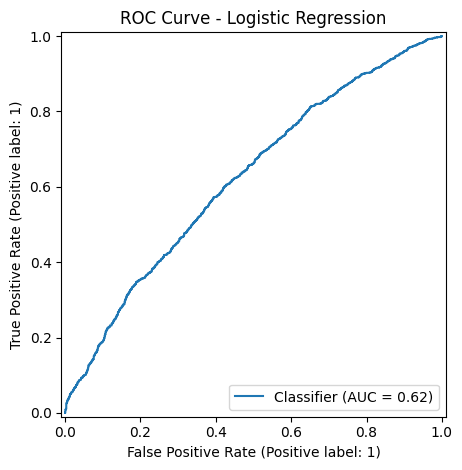

Decision Tree
              precision    recall  f1-score   support

        Left       0.52      0.54      0.53      1247
       Right       0.71      0.70      0.71      2030

    accuracy                           0.64      3277
   macro avg       0.62      0.62      0.62      3277
weighted avg       0.64      0.64      0.64      3277



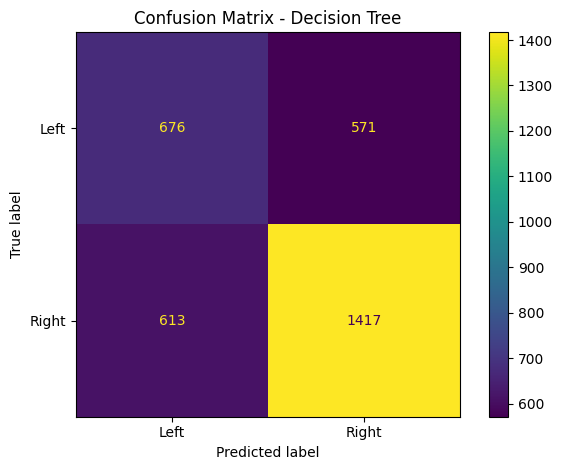

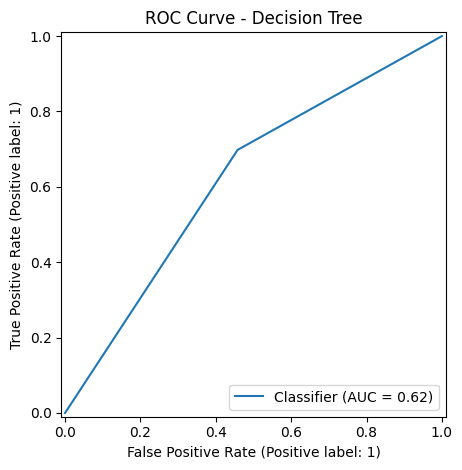

Random Forest
              precision    recall  f1-score   support

        Left       0.73      0.50      0.59      1247
       Right       0.74      0.88      0.81      2030

    accuracy                           0.74      3277
   macro avg       0.73      0.69      0.70      3277
weighted avg       0.74      0.74      0.73      3277



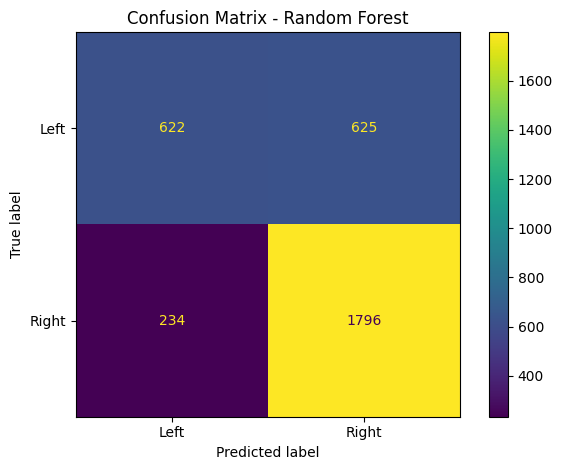

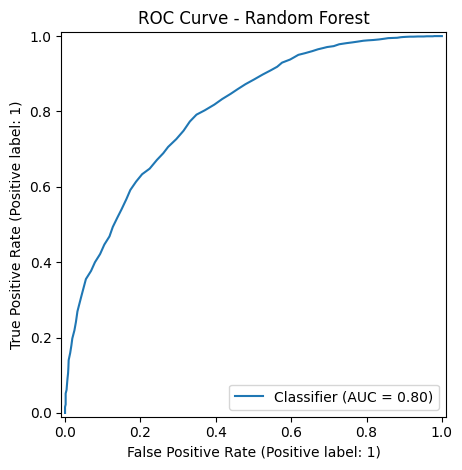

Gradient Boosting
              precision    recall  f1-score   support

        Left       0.72      0.47      0.57      1247
       Right       0.73      0.89      0.80      2030

    accuracy                           0.73      3277
   macro avg       0.72      0.68      0.68      3277
weighted avg       0.72      0.73      0.71      3277



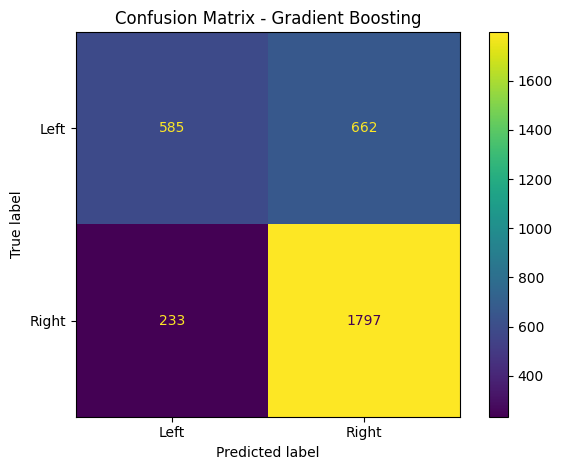

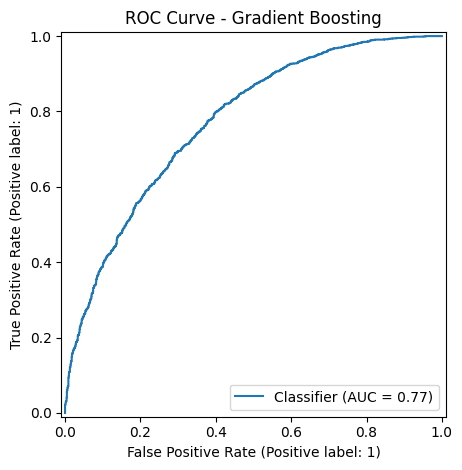

XGBoost
              precision    recall  f1-score   support

        Left       0.69      0.57      0.62      1247
       Right       0.76      0.84      0.80      2030

    accuracy                           0.74      3277
   macro avg       0.72      0.70      0.71      3277
weighted avg       0.73      0.74      0.73      3277



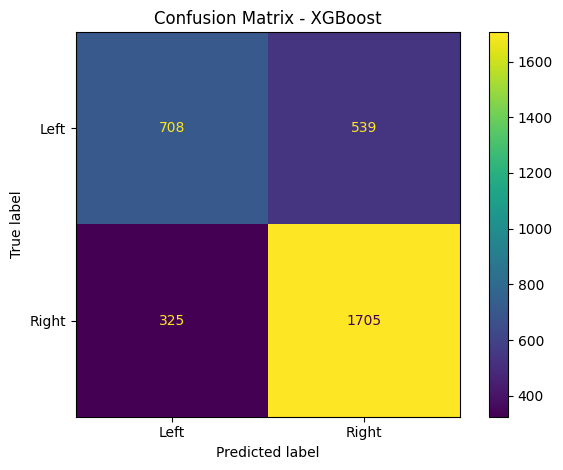

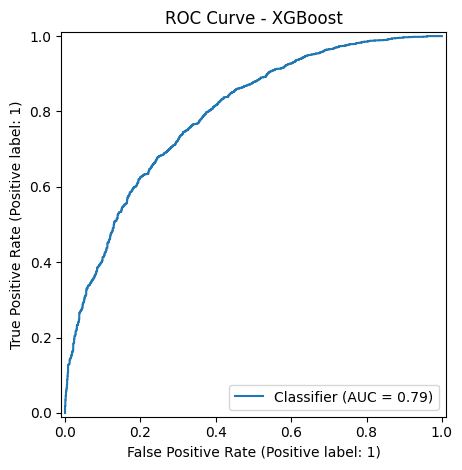

In [28]:
trained_models = {}
results = []

for model_name, model in models.items():
    trained_model, metrics = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        model_name=model_name
    )

    trained_models[model_name] = trained_model
    results.append(metrics)

In [29]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
)

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.737870,0.741842,0.884729,0.807010,0.800032
3,Gradient Boosting,0.726884,0.730785,0.885222,0.800624,0.773216
4,XGBoost,0.736344,0.759804,0.839901,0.797847,0.792124
1,Decision Tree,0.638694,0.712777,0.698030,0.705326,0.620065
0,Logistic Regression,0.586207,0.698469,0.584236,0.636266,0.621697


In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["model"],
    results_df["f1_score"]
)

plt.ylabel("F1-score")
plt.xlabel("Model")
plt.title("Model comparison based on F1-score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/model_comparison_f1_score.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["model"],
    results_df["roc_auc"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model comparison based on ROC-AUC")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/model_comparison_roc_auc.png", dpi=300, bbox_inches="tight")
plt.show()

------------------------------

## 6. Ajuste de hiperparámetros para el modelo Random Forest

Buscamos los mejores hiperparámetros para el mejor modelo que arrojó el análisis anterior

In [31]:
param_grid_rf = {
    "n_estimators": [300, 500],
    "max_depth": [15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters:")
print(grid_search_rf.best_params_)

print("Best cross-validation F1-score:")
print(grid_search_rf.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation F1-score:
0.8084550699576084


Optimized Random Forest
              precision    recall  f1-score   support

        Left       0.75      0.50      0.60      1247
       Right       0.75      0.90      0.82      2030

    accuracy                           0.75      3277
   macro avg       0.75      0.70      0.71      3277
weighted avg       0.75      0.75      0.73      3277



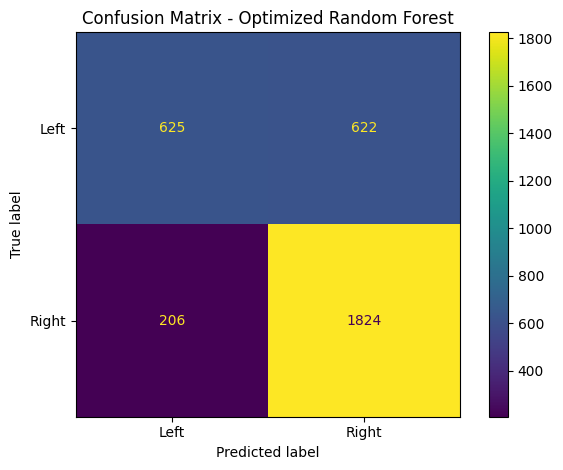

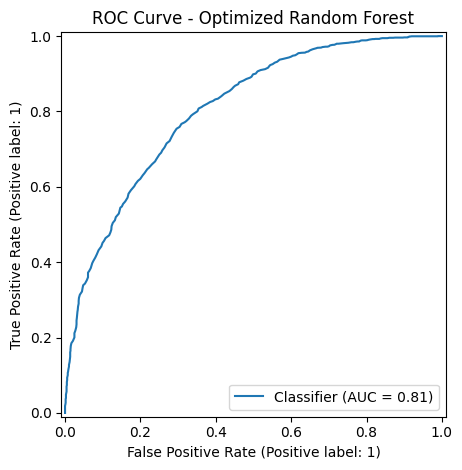

In [33]:
optimized_rf = grid_search_rf.best_estimator_

optimized_rf, optimized_rf_metrics = evaluate_model(
    model=optimized_rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model_name="Optimized Random Forest"
)

In [35]:
trained_models["Optimized Random Forest"] = optimized_rf
results.append(optimized_rf_metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="f1_score",
    ascending=False
)

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
5,Optimized Random Forest,0.747330,0.745707,0.898522,0.815013,0.805975
2,Random Forest,0.737870,0.741842,0.884729,0.807010,0.800032
3,Gradient Boosting,0.726884,0.730785,0.885222,0.800624,0.773216
4,XGBoost,0.736344,0.759804,0.839901,0.797847,0.792124
1,Decision Tree,0.638694,0.712777,0.698030,0.705326,0.620065
0,Logistic Regression,0.586207,0.698469,0.584236,0.636266,0.621697


In [36]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Optimized Random Forest


In [37]:
joblib.dump(best_model, "../app/best_model.pkl")

print("Best model saved.")

Best model saved.


In [32]:
best_rf = grid_search.best_estimator_

print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
